<a href="https://colab.research.google.com/github/imranasalisu1/Hendeb_project/blob/main/Module6_QSPR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**3D-QSPR MODELING USING MACHINE ALGORITHMS**

This module explores prediction of physicochemical properties using molecular
descriptors. It focuses on properties such as solubility, lipophilicity, and boiling point.
Machine learning models are used for regression analysis. The relationship between
structure and properties is examined. Practical applications in drug development and
environmental science are discussed.

---
In both environmental science and drug design, the behavior of a molecule is dictated by a suite of physicochemical properties that determine how it moves through biological systems or the ecosystem. While **LogP** (octanol-water partition coefficient) is a cornerstone for assessing lipophilicity, several other parameters are equally critical for predicting a compound's ultimate fate and efficacy.

- **Aqueous Solubility (S or LogS)** is arguably the most vital property following lipophilicity. In drug design, a compound must dissolve in the aqueous environment of the gastrointestinal tract to be absorbed; consequently, low solubility frequently leads to poor bioavailability and remains a primary cause of clinical failure. From an environmental perspective, solubility determines how easily a contaminant washes into groundwater or is diluted in surface water, with high solubility often facilitating faster transport through soil.

- **Topological Polar Surface Area (TPSA)**, which measures the surface sum of all polar atoms like Oxygen and Nitrogen, serves as a key predictor of membrane permeability. In pharmacological contexts, a TPSA below 140Å^2 is generally required for oral absorption, while values under 60Å^2 are typically necessary to cross the blood-brain barrier. Environmentally, polar compounds interact more strongly with clay and organic matter through hydrogen bonding, which significantly limits their overall mobility in the ecosystem.

- The **Dissociation Constant (pKa)** indicates the pH at which a molecule is 50% ionized, a state that profoundly affects both solubility and membrane permeability. Because most drugs are weak acids or bases, their ionization state at a physiological pH of 7.4 determines how easily they cross lipid bilayers, as neutral forms permeate more readily than charged ones. Similarly, pKa dictates whether a pesticide or pollutant will carry a charge in specific soil types, influencing whether the species will volatilize into the air or leach into water sources.

- **Molecular Weight (MW)** and **Hydrogen Bond** parameters (Donors and Acceptors) represent fundamental structural constraints. Following Lipinski's Rule of 5, a MW under 500Da is preferred for oral drugs to maintain passive diffusion, while larger environmental molecules tend to have lower volatility and accumulate in sediments. Furthermore, high HBD/HBA counts increase the energy required for a molecule to desolvate and pass through membranes, while also dictating the "stickiness" of environmental pollutants to biological surfaces.

- Finally, the **Rotatable Bond Count** measures molecular flexibility, which influences how a molecule fits into target protein pockets and its likelihood of oral bioavailability. High flexibility, often defined as more than 10 rotatable bonds, is frequently associated with reduced absorption in drug design. In environmental research, rigid molecules often exhibit higher melting points and distinct degradation rates compared to their more flexible isomers, directly impacting their potential for bioaccumulation.

This cell installs the necessary tools for interacting with the ChEMBL database, calculating molecular descriptors with RDKit, and interpreting the model with SHAP.

In [1]:
!pip install rdkit chembl_webresource_client xgboost shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import os
import zipfile
import io
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, MolSurf
from chembl_webresource_client.new_client import new_client
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.neighbors import NearestNeighbors
from google.colab import files

# Global state to store model objects
STATE = {}

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.6 MB/s eta 0:00:00


- chembl_webresource_client: This allows us to search and download bioactivity and physicochemical data directly from the ChEMBL database.

- rdkit: The industry-standard library for cheminformatics, used here to convert SMILES into 2D chemical descriptors.

- shap: A game-theoretic approach to explain the output of machine learning models, helping identify which descriptors drive the predicted properties.

In [15]:
SEARCH_TERM = 'EGFR Kinase'    # ← CHANGE THIS

print(f'🔍 Searching ChEMBL for: "{SEARCH_TERM}"\n')
target_api = new_client.target
results = target_api.search(SEARCH_TERM)
df_targets = pd.DataFrame(list(results))[
    ['target_chembl_id','pref_name','target_type','organism']
].head(15)

print(f'Found {len(df_targets)} targets:\n')
display(df_targets)
print('\n💡 Copy the target_chembl_id you want and paste it in the configuration cell below.')

🔍 Searching ChEMBL for: "EGFR Kinase"

Found 15 targets:



,target_chembl_id,pref_name,target_type,organism
0,CHEMBL203,Epidermal growth factor receptor,SINGLE PROTEIN,Homo sapiens
1,CHEMBL3608,Epidermal growth factor receptor,SINGLE PROTEIN,Mus musculus
2,CHEMBL4523747,EGFR/PPP1CA,PROTEIN-PROTEIN INTERACTION,Homo sapiens
3,CHEMBL5465557,CCN2-EGFR,PROTEIN-PROTEIN INTERACTION,Homo sapiens
4,CHEMBL4523680,Protein cereblon/Epidermal growth factor receptor,PROTEIN-PROTEIN INTERACTION,Homo sapiens
5,CHEMBL3137284,MER intracellular domain/EGFR extracellular do...,CHIMERIC PROTEIN,Homo sapiens
6,CHEMBL4523998,von Hippel-Lindau disease tumor suppressor/EGFR,PROTEIN-PROTEIN INTERACTION,Homo sapiens
7,CHEMBL2111431,Epidermal growth factor receptor and ErbB2 (HE...,PROTEIN FAMILY,Homo sapiens
8,CHEMBL6066845,Glucose-induced degradation protein 4 homolog/...,PROTEIN-PROTEIN INTERACTION,Homo sapiens
9,CHEMBL2363049,Epidermal growth factor receptor,PROTEIN FAMILY,Homo sapiens



💡 Copy the target_chembl_id you want and paste it in the configuration cell below.


In [16]:
from chembl_webresource_client.new_client import new_client
import pandas as pd
import numpy as np

# Initialize client
activities = new_client.activity

# Target: EGFR Kinase
target_id = "CHEMBL203"

print("Retrieving EGFR Kinase bioactivity data...")

# Step 1: Retrieve more data (IC50 + Ki)
res = activities.filter(target_chembl_id=target_id)\
                .filter(standard_type__in=["IC50", "Ki"])\
                .filter(standard_units="nM")\
                .only('molecule_chembl_id',
                      'canonical_smiles',
                      'standard_value',
                      'standard_type')

# Convert to DataFrame
df = pd.DataFrame.from_dict(res)

print("Raw data size:", len(df))

# Step 2: Clean data
df = df.dropna(subset=['canonical_smiles', 'standard_value'])

# Convert to numeric
df['standard_value'] = pd.to_numeric(df['standard_value'], errors='coerce')
df = df.dropna(subset=['standard_value'])

print("After cleaning:", len(df))

# Step 3: Remove extreme/outlier values (optional but recommended)
df = df[df['standard_value'] > 0]
df = df[df['standard_value'] < 1e7]  # remove extremely large values

print("After filtering outliers:", len(df))

# Step 4: Aggregate duplicates (IMPORTANT)
# Instead of dropping duplicates, take mean activity per molecule
df_grouped = df.groupby('canonical_smiles').agg({
    'standard_value': 'mean'
}).reset_index()

print("After grouping duplicates:", len(df_grouped))

# Step 5: Convert to pIC50 (optional but useful for ML)
df_grouped['pIC50'] = 9 - np.log10(df_grouped['standard_value'])

# Step 6: Create activity labels (optional)
# Example threshold: 1000 nM
df_grouped['activity_class'] = df_grouped['standard_value'].apply(
    lambda x: 1 if x <= 1000 else 0
)

print("\nFinal dataset size:", len(df_grouped))
df_grouped.head()

Retrieving EGFR Kinase bioactivity data...
Raw data size: 25603
After cleaning: 25429
After filtering outliers: 25319
After grouping duplicates: 14069

Final dataset size: 14069


,canonical_smiles,standard_value,pIC50,activity_class
0,Br.CC(Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1ccc(C(...,4608.0,5.336488,0
1,Br.CC(Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1cccc2c...,1008.0,5.996539,0
2,Br.CC[C@@H](Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1...,4.0,8.397940,1
3,Br.C[C@@H](Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1c...,62.0,7.207608,1
4,Br.C[C@@H](Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1c...,3.8,8.420216,1


- target.filter: We use a text search to find the specific biological target associated with the malaria parasite.

- activities.filter: We pull the numerical "values" which represent our target physicochemical property for the QSPR model.

- Data Cleaning: We remove any entries missing SMILES strings or experimental values to ensure the model trains on complete data.

In [26]:
def get_advanced_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if not mol: return None
    # Calculating key drug-design and environmental properties
    props = {
        'MW': Descriptors.MolWt(mol),
        'LogP': Descriptors.MolLogP(mol),
        'TPSA': MolSurf.TPSA(mol),
        'HBD': Lipinski.NumHDonors(mol),
        'HBA': Lipinski.NumHAcceptors(mol),
        'RotBonds': Lipinski.NumRotatableBonds(mol),
        'AromaticRings': Lipinski.NumAromaticRings(mol)
    }
    # Add all other standard RDKit 2D descriptors
    props.update(Descriptors.CalcMolDescriptors(mol))
    return props

# Apply to dataset
df_train['desc_dict'] = df_train['canonical_smiles'].apply(get_advanced_descriptors)
X = pd.DataFrame(df_train['desc_dict'].tolist()).dropna(axis=1).select_dtypes(include=[np.number])
y = df_train['value'].astype(float)

# Feature Selection
selector = VarianceThreshold(threshold=0.01)
X_f = pd.DataFrame(selector.fit_transform(X), columns=X.columns[selector.get_support()])
corr = X_f.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [c for c in upper.columns if any(upper[c] > 0.95)]
X_final = X_f.drop(columns=to_drop)

# Save for later use
STATE['features'] = X_final.columns.tolist()
STATE['medians'] = X_final.median()
scaler = StandardScaler()
STATE['X_sc'] = scaler.fit_transform(X_final)
STATE['scaler'] = scaler
STATE['y'] = y

- get_advanced_descriptors: This function extracts the 2D "fingerprint" of the molecule, including TPSA (Polar Surface Area) and RotBonds (Flexibility).

- VarianceThreshold: Removes "flat" descriptors that don't change across molecules and therefore provide no predictive value.

- Correlation Filter: Removes redundant descriptors (correlation > 0.95) to prevent the model from becoming biased or overfitted.

In [27]:
X_sc = STATE['X_sc']; y = STATE['y']
X_tr, X_te, y_tr, y_te = train_test_split(X_sc, y, test_size=0.2, random_state=42)

models = {
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, objective='reg:squarederror'),
    "SVM": SVR(kernel='rbf', C=1.0)
}

results = {}
for name, model in models.items():
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    results[name] = {'R2': r2_score(y_te, preds), 'MAE': mean_absolute_error(y_te, preds)}
    print(f"{name} | R2: {results[name]['R2']:.3f} | MAE: {results[name]['MAE']:.3f}")

STATE['best_name'] = max(results, key=lambda k: results[k]['R2'])
STATE['best_model'] = models[STATE['best_name']]

Random Forest | R2: 0.030 | MAE: 8.968
XGBoost | R2: -0.006 | MAE: 9.448
SVM | R2: -0.201 | MAE: 12.409


- train_test_split: We hold out 20% of the data to test the model on "unseen" molecules.

- R2 (R-Squared): Measures how well the model explains the variance of the property (closer to 1.0 is better).

- MAE (Mean Absolute Error): Shows the average error in the same units as the property (e.g., LogP units).

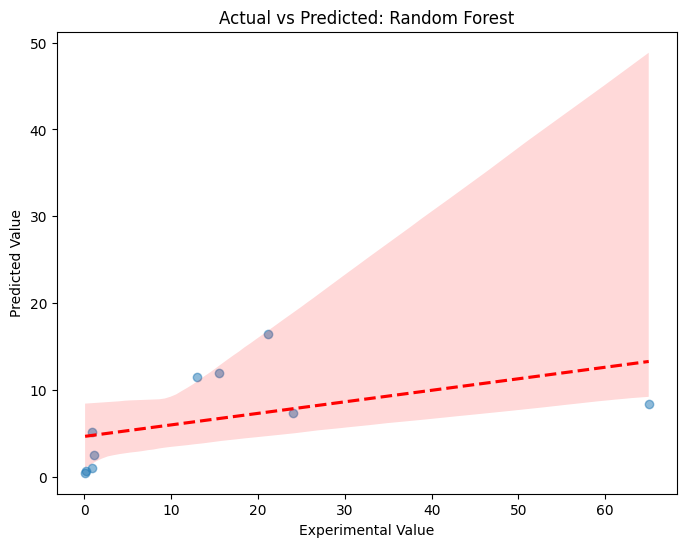

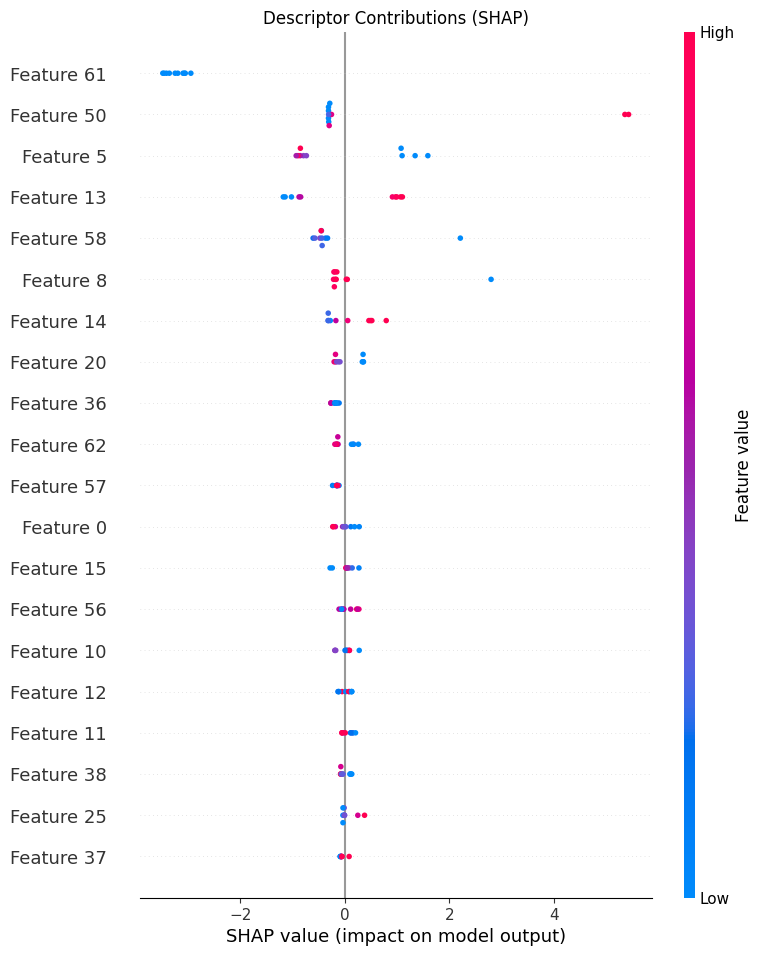

In [28]:
best_model = STATE['best_model']
y_pred = best_model.predict(X_te)

# 1. Actual vs Predicted Plot
plt.figure(figsize=(8,6))
sns.regplot(x=y_te, y=y_pred, scatter_kws={'alpha':0.5}, line_kws={'color':'red', 'ls':'--'})
plt.title(f'Actual vs Predicted: {STATE["best_name"]}')
plt.xlabel('Experimental Value'); plt.ylabel('Predicted Value')
plt.savefig('actual_vs_predicted.png')
plt.show()

# 2. SHAP Descriptor Contributions
explainer = shap.Explainer(best_model, X_tr)
shap_values = explainer(X_te)
plt.figure()
shap.summary_plot(shap_values, X_te, show=False)
plt.title('Descriptor Contributions (SHAP)')
plt.savefig('descriptor_contributions.png')

- Actual vs Predicted Plot: If the dots follow the red dashed line, the model is highly accurate.

- SHAP Summary Plot: This ranks which descriptors (like MW or HBD) have the most significant impact on the final prediction, helping you understand the "why" behind a prediction.

In [33]:
print('📂 Upload your molecular library CSV file:')
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Auto-detect separator and decimal
content = uploaded[filename].decode('utf-8', errors='replace')
first_line = content.split('\n')[0]
sep = ';' if first_line.count(';') > first_line.count(',') else ','
print(f'\nDetected separator: {repr(sep)}')

df_lib = pd.read_csv(io.BytesIO(uploaded[filename]), sep=sep,
                     decimal=',', encoding='utf-8', low_memory=False)

# Auto-detect SMILES column
smiles_candidates = ['Canonical_SMILES','SMILES','smiles','canonical_smiles',
                     'structure','Structure','mol','MOL','Smiles']
col_smi = next((c for c in smiles_candidates if c in df_lib.columns), None)
if col_smi is None:
    for c in df_lib.columns:
        if any(k in c.lower() for k in ['smile','struct','smil']): col_smi = c; break

# Auto-detect ID/name column
id_candidates = ['id','ID','name','Name','compound_id','molecule_chembl_id',
                 'PNDBCOL_id','nombre','synonymsName','compound_name']
col_id = next((c for c in id_candidates if c in df_lib.columns), None)

print(f'\n✅ File loaded: {filename}')
print(f'   Rows: {len(df_lib)} | Columns: {df_lib.shape[1]}')
print(f'   SMILES column detected: "{col_smi}"')
print(f'   ID/name column detected: "{col_id}"')
display(df_lib.head(3))

STATE['df_lib_raw'] = df_lib
STATE['col_smi'] = col_smi
STATE['col_id']  = col_id

📂 Upload your molecular library CSV file:


Saving neem_phytochemicals_pubchem.csv to neem_phytochemicals_pubchem (4).csv

Detected separator: ','

✅ File loaded: neem_phytochemicals_pubchem (4).csv
   Rows: 236 | Columns: 3
   SMILES column detected: "Canonical_SMILES"
   ID/name column detected: "None"


,Phytochemical,PubChem_CID,Canonical_SMILES
0,Nimbiol,11119228,CC1=CC2=C(C=C1O)C3(CCCC(C3CC2=O)(C)C)C
1,6-Deacetylnimbin,10505484,CC1=C2C(CC1C3=COC=C3)OC4C2(C(C5(C(C4O)C(C=CC5=...
2,Kulinone,44567124,CC(CCC=C(C)C)C1C(CC2(C1(CCC3C2=CCC4C3(CCC(=O)C...


In [35]:
# Predictions and AD Check
preds_lib = best_model.predict(X_lib_sc)
# Calculate h_star for Applicability Domain
X_tr_sc = X_tr
XTX_inv = np.linalg.pinv(np.dot(X_tr_sc.T, X_tr_sc))
leverages = np.array([np.dot(np.dot(x, XTX_inv), x.T) for x in X_lib_sc])
h_star = 3 * (X_tr_sc.shape[1] + 1) / X_tr_sc.shape[0]
in_ad = leverages <= h_star

lib_df['Predicted_Value'] = preds_lib
lib_df['Inside_AD'] = in_ad
lib_df.to_csv('screening_results.csv', index=False)
print("Screening Complete. Results saved.")

Screening Complete. Results saved.


- Leverage (h): We calculate how "chemically different" the library molecules are from the training set:

 - This is the threshold. If a molecule is "Outside AD," the prediction is an extrapolation and should be treated with caution.

In [40]:
def predict_single_qspr(smi):
    # Clean accidental quotes or whitespace from input
    smi = smi.strip().replace('"', '').replace("'", "")

    # Calculate all physicochemical descriptors
    desc = get_advanced_descriptors(smi)
    if not desc:
        print("❌ Invalid SMILES: Please check the chemical structure.")
        return

    # Prepare data for the model
    X_new = pd.DataFrame([desc])[STATE['features']].fillna(STATE['medians'])
    X_new_sc = STATE['scaler'].transform(X_new)

    # Predict the target property using your best-performing model
    val = STATE['best_model'].predict(X_new_sc)[0]

    # Display the full Physicochemical Profile
    print(f"{'='*50}")
    print(f"       QSPR PREDICTION PROFILE")
    print(f"{'='*50}")
    print(f"SMILES: {smi}")
    print(f"{'-'*50}")
    print(f"PREDICTED VALUE:      {val:.4f}")
    print(f"{'-'*50}")
    print(f"Molecular Weight:      {desc['MW']:.2f} Da")
    print(f"Lipophilicity (LogP):  {desc['LogP']:.2f}")
    print(f"Polar Surface Area:    {desc['TPSA']:.2f} Å²")
    print(f"H-Bond Donors (HBD):   {int(desc['HBD'])}")
    print(f"H-Bond Acceptors (HBA): {int(desc['HBA'])}")
    print(f"Rotatable Bonds:       {int(desc['RotBonds'])}")
    print(f"Aromatic Rings:        {int(desc['AromaticRings'])}")
    print(f"{'='*50}")

# Execution
user_input = input("Enter SMILES: ")
predict_single_qspr(user_input)

Enter SMILES: CC(=O)OC1=CC=CC=C1C(=O)O
       QSPR PREDICTION PROFILE
SMILES: CC(=O)OC1=CC=CC=C1C(=O)O
--------------------------------------------------
PREDICTED VALUE:      12.8370
--------------------------------------------------
Molecular Weight:      180.16 Da
Lipophilicity (LogP):  1.31
Polar Surface Area:    63.60 Å²
H-Bond Donors (HBD):   1
H-Bond Acceptors (HBA): 3
Rotatable Bonds:       2
Aromatic Rings:        1
